Loaded chunk 0 from sample_lowerA-Henry-20260403140615.npz
Subject: Henry, gesture: lowerA, chirp-detected channel: L


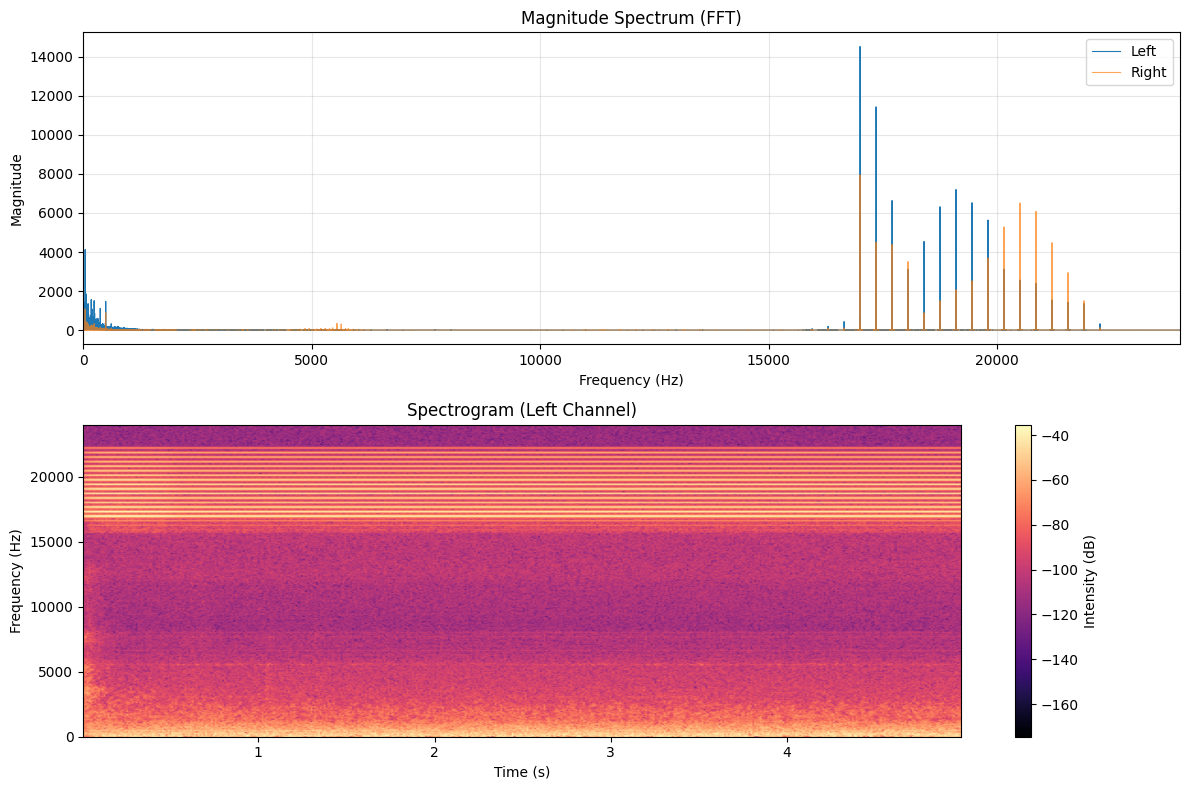

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Audio, display

# Load one chunk directly from aggregated chunked NPZ data
chunked_path = Path("data") / "preliminary_data" / "chunked" / "lowerA" / "sample_lowerA-Henry-20260403140615.npz"
chunk_index = 0

with np.load(chunked_path) as chunk_data:
    chunk_audio = chunk_data["audio"]
    sample_rate = int(chunk_data["sample_rate"])
    channels = int(chunk_data["channels"])
    dtype = str(chunk_data["dtype"])
    subject = str(chunk_data["subject"])
    gesture = str(chunk_data["gesture"])
    chunk_channels = chunk_data["chunk_channels"]

audio_stereo = chunk_audio[chunk_index].astype(np.float32)
selected_channel = str(chunk_channels[chunk_index])

if audio_stereo.ndim == 2 and channels > 1:
    audio_left = audio_stereo[:, 0]
    audio_right = audio_stereo[:, 1]
else:
    audio_left = audio_stereo.reshape(-1)
    audio_right = audio_left.copy()

left_peak = np.max(np.abs(audio_left))
if left_peak > 0:
    audio_left = audio_left / left_peak

right_peak = np.max(np.abs(audio_right))
if right_peak > 0:
    audio_right = audio_right / right_peak

print(f"Loaded chunk {chunk_index} from {chunked_path.name}")
print(f"Subject: {subject}, gesture: {gesture}, chirp-detected channel: {selected_channel}")

# Keep the legacy variable name for downstream cells that expect a single channel.
audio = audio_left

# Play each channel separately
display(Audio(audio_left, rate=sample_rate))
display(Audio(audio_right, rate=sample_rate))

# Spectral analysis plots
n = len(audio_left)
freqs = np.fft.rfftfreq(n, d=1 / sample_rate)
spectrum_left = np.abs(np.fft.rfft(audio_left))
spectrum_right = np.abs(np.fft.rfft(audio_right))

plt.figure(figsize=(12, 8))

# Frequency spectrum (FFT magnitude)
plt.subplot(2, 1, 1)
plt.plot(freqs, spectrum_left, linewidth=0.8, label="Left")
plt.plot(freqs, spectrum_right, linewidth=0.8, label="Right", alpha=0.7)
plt.title("Magnitude Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(0, sample_rate / 2)
plt.legend()
plt.grid(alpha=0.3)

# Spectrogram
plt.subplot(2, 1, 2)
plt.specgram(audio_left, NFFT=1024, Fs=sample_rate, noverlap=512, cmap="magma")
plt.title("Spectrogram (Left Channel)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")

plt.tight_layout()
plt.show()

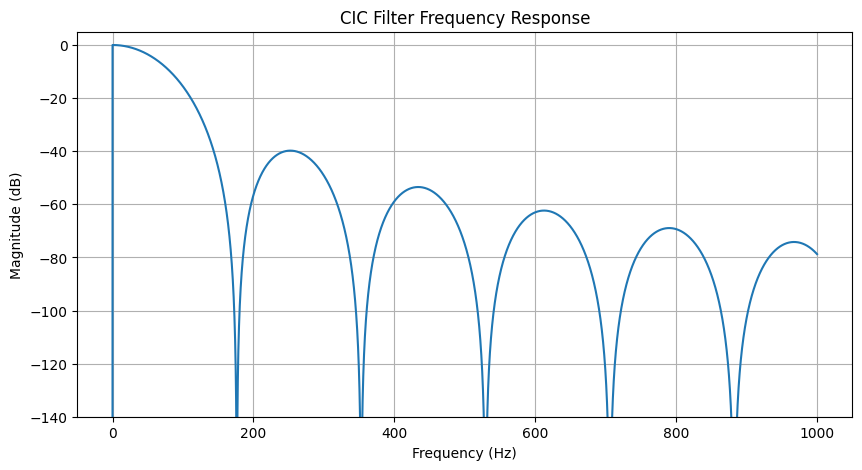

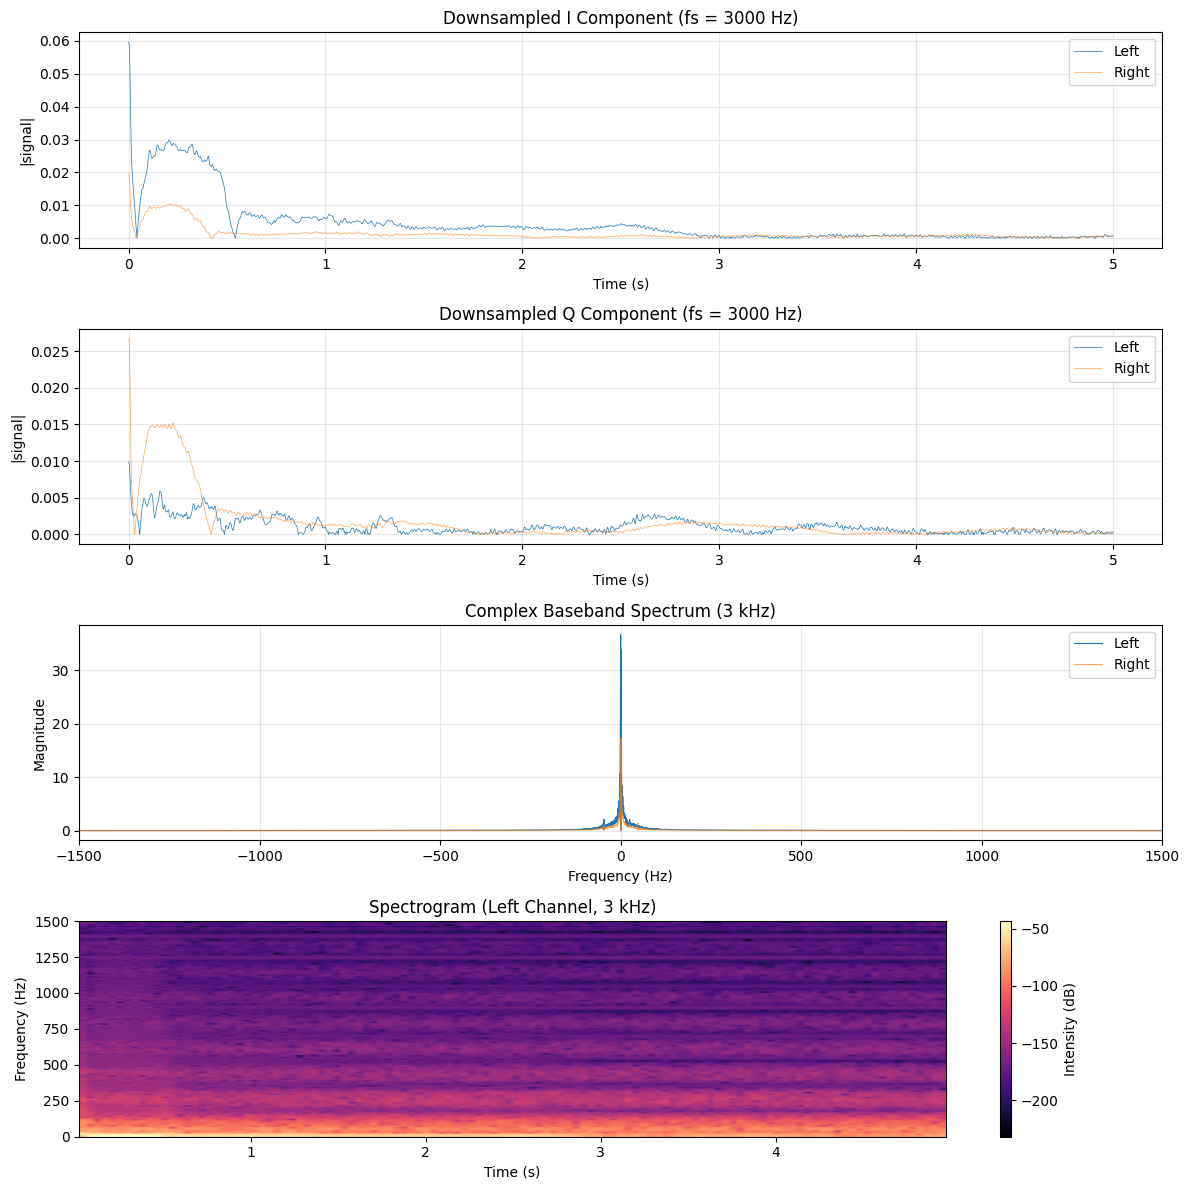

In [24]:
def lowpass_cic_filter(signal, decimation_factor, difference_delay=1, stages=3):
    signal = signal.astype(np.complex128)

    # Integrators
    for _ in range(stages):
        signal = np.cumsum(signal)

    # Decimate
    signal = signal[::decimation_factor]

    # Combs
    for _ in range(stages):
        delayed = np.concatenate((np.zeros(difference_delay, dtype=signal.dtype),
                                  signal[:-difference_delay]))
        signal = signal - delayed
        
    # normalize gain
    signal /= (decimation_factor * difference_delay) ** stages

    return signal

def down_convert(audio, sample_rate, carrier_freq):
    t = np.arange(len(audio)) / sample_rate
    iSignal = audio * np.cos(2 * np.pi * carrier_freq * t)
    qSignal = audio * -np.sin(2 * np.pi * carrier_freq * t)
    return iSignal + 1j * qSignal

# Carrier settings from make_signal.py
freq_gap = 350
freq_count = 16
carrier_freqs = [17000 + freq_gap * j for j in range(freq_count)]

# Example usage of down-conversion and CIC filter
carrier_freq = carrier_freqs[0]  # Hz
downconverted_left = down_convert(audio_left, sample_rate, carrier_freq)
downconverted_right = down_convert(audio_right, sample_rate, carrier_freq)

# We select the parameters so that the ﬁrstand second zeros of the ﬁlter appear at 175 Hz and 350 Hz. Thepass-band of the CIC ﬁlter is 0 ∼ 100 Hz, which corresponds to themovements with a speed lower than 0.95 m/s when the wavelengthis 1.9 cm. The second zero of the ﬁlter appears at 350 Hz so thatthe signals at (f ± 350) Hz will be attenuated by more than 120dB. Thus, to minimize the interferences from adjacent frequencies,we use a frequency interval of 350 Hz when the speaker transmitsmultiple frequencies simultaneously. To achieve better computa-tional efﬁciency, we do not use a frequency compensate FIR ﬁlterafter the CIC.
decimation_factor = 16
difference_delay = 17
stages = 3
filtered_left = lowpass_cic_filter(downconverted_left, decimation_factor, difference_delay, stages)
filtered_right = lowpass_cic_filter(downconverted_right, decimation_factor, difference_delay, stages)

# Static removal: subtract the complex mean from each channel.
filtered_left = filtered_left - np.mean(filtered_left)
filtered_right = filtered_right - np.mean(filtered_right)

# CIC parameters
N = 3      # number of sections
R = 16     # decimation ratio
M = 17     # differential delay
fs = 48000 # sample rate (change as needed)

# Frequency axis
f = np.linspace(0, 1000, 20000)
w = 2 * np.pi * f / fs

# Avoid division by zero
eps = 1e-12
num = np.sin(w * R * M / 2)
den = np.sin(w / 2) + eps

# CIC magnitude response
H = (num / den) ** N
H = np.abs(H)

# Normalize
H = H / np.max(H)

# Convert to dB
H_db = 20 * np.log10(H + 1e-12)

# Plot
plt.figure(figsize=(10,5))
plt.plot(f, H_db)
plt.title("CIC Filter Frequency Response")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.ylim([-140, 5])
plt.grid(True)
plt.show()

# Plot down-converted and filtered signal spectrum
new_sample_rate = sample_rate / decimation_factor  # 3000 Hz
t_filtered = np.arange(len(filtered_left)) / new_sample_rate

freqs_filt = np.fft.fftshift(np.fft.fftfreq(len(filtered_left), d=1 / new_sample_rate))
spectrum_left = np.abs(np.fft.fftshift(np.fft.fft(filtered_left)))
spectrum_right = np.abs(np.fft.fftshift(np.fft.fft(filtered_right)))

plt.figure(figsize=(12, 12))

# Time-domain magnitude
plt.subplot(4, 1, 1)
plt.plot(t_filtered, np.abs(filtered_left.real), linewidth=0.5, label="Left")
plt.plot(t_filtered, np.abs(filtered_right.real), linewidth=0.5, label="Right", alpha=0.7)
plt.title(f"Downsampled I Component (fs = {new_sample_rate:.0f} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("|signal|")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(4, 1, 2)
plt.plot(t_filtered, np.abs(filtered_left.imag), linewidth=0.5, label="Left")
plt.plot(t_filtered, np.abs(filtered_right.imag), linewidth=0.5, label="Right", alpha=0.7)
plt.title(f"Downsampled Q Component (fs = {new_sample_rate:.0f} Hz)")
plt.xlabel("Time (s)")
plt.ylabel("|signal|")
plt.legend()
plt.grid(alpha=0.3)

# Frequency spectrum
plt.subplot(4, 1, 3)
plt.plot(freqs_filt, spectrum_left, linewidth=0.8, label="Left")
plt.plot(freqs_filt, spectrum_right, linewidth=0.8, label="Right", alpha=0.7)
plt.title("Complex Baseband Spectrum (3 kHz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.xlim(-new_sample_rate / 2, new_sample_rate / 2)
plt.legend()
plt.grid(alpha=0.3)

# Spectrogram
plt.subplot(4, 1, 4)
plt.specgram(np.real(filtered_left), NFFT=256, Fs=new_sample_rate, noverlap=128, cmap="magma")
plt.title("Spectrogram (Left Channel, 3 kHz)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.colorbar(label="Intensity (dB)")

plt.tight_layout()
plt.show()


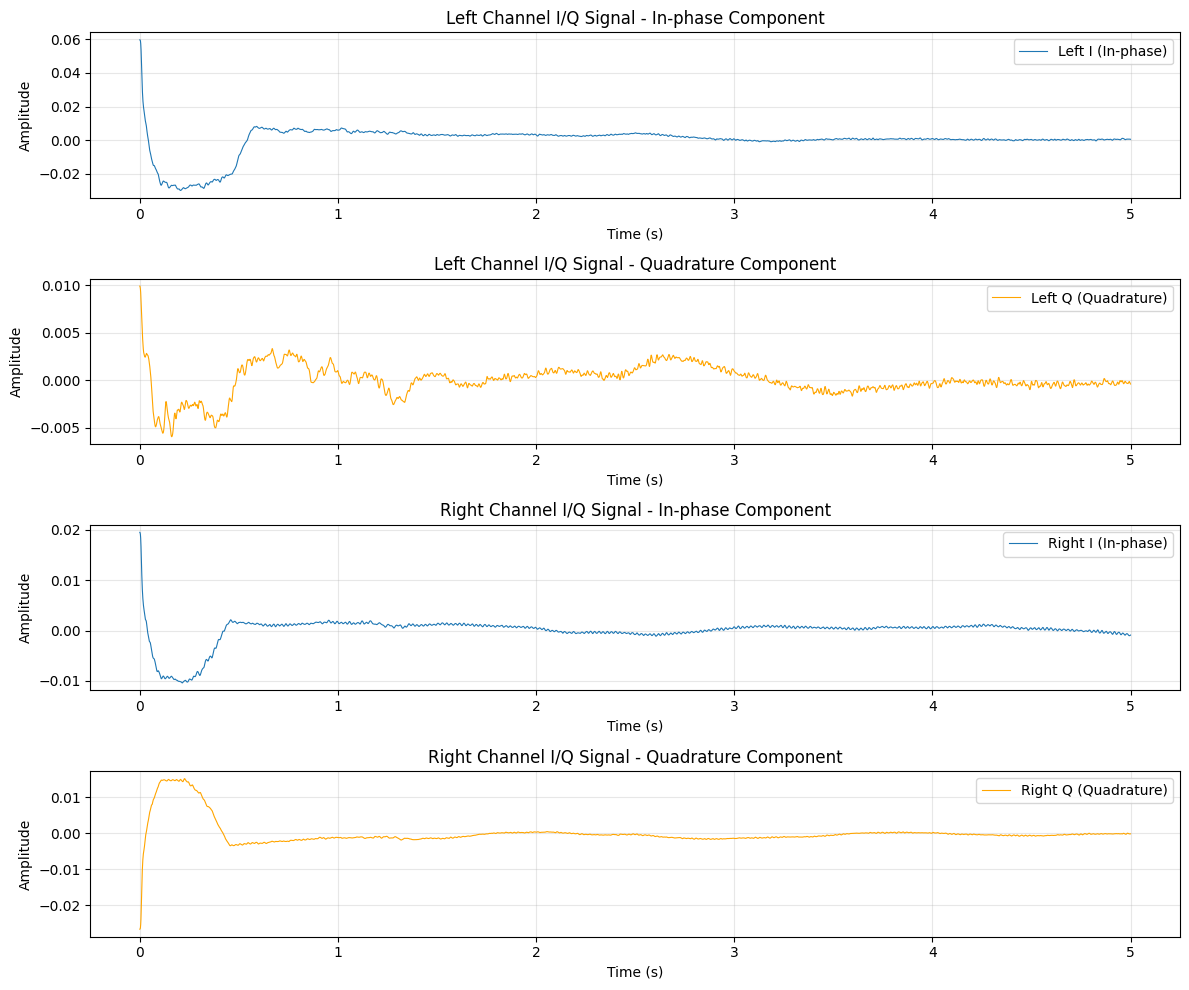

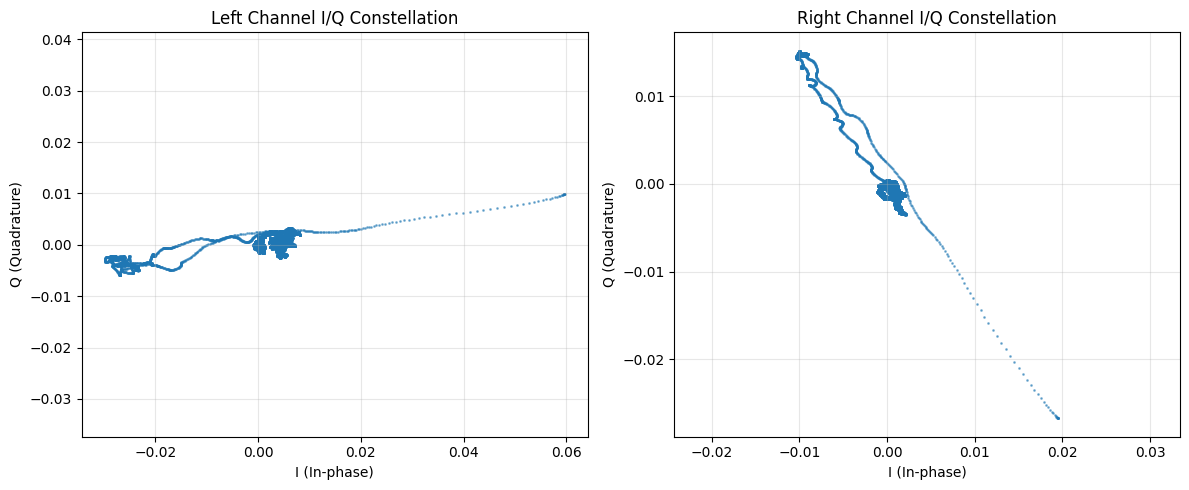

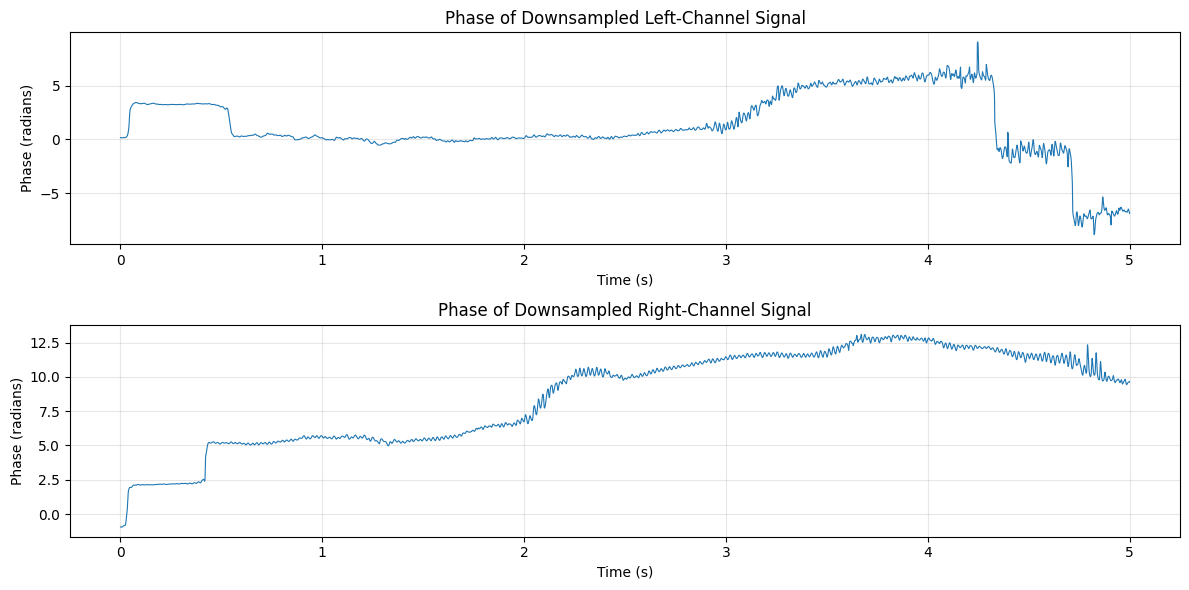

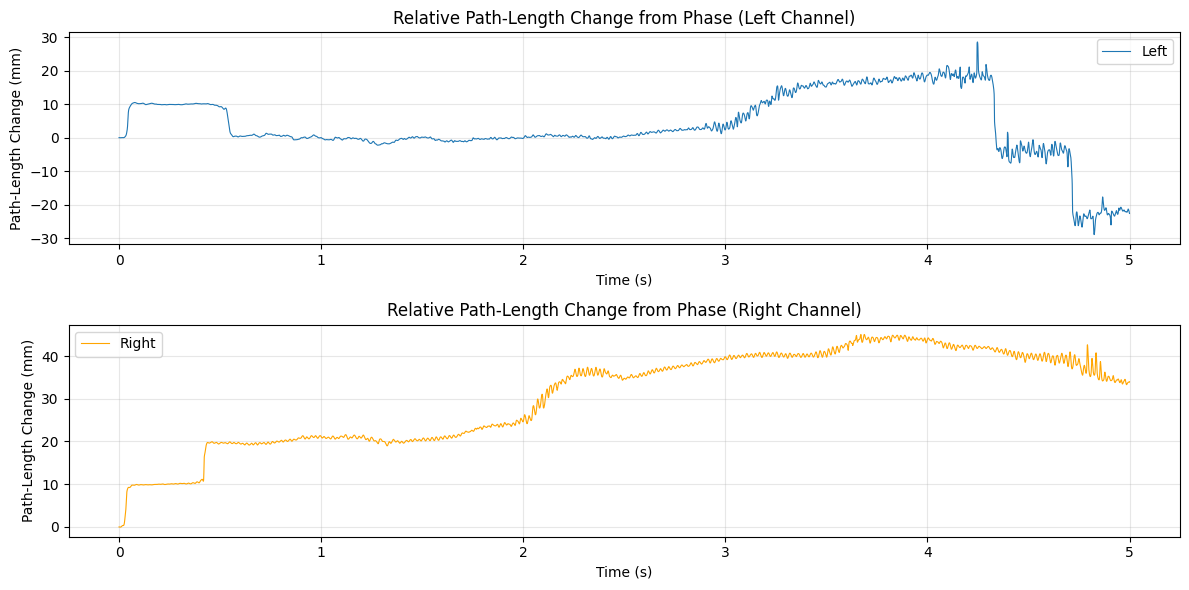

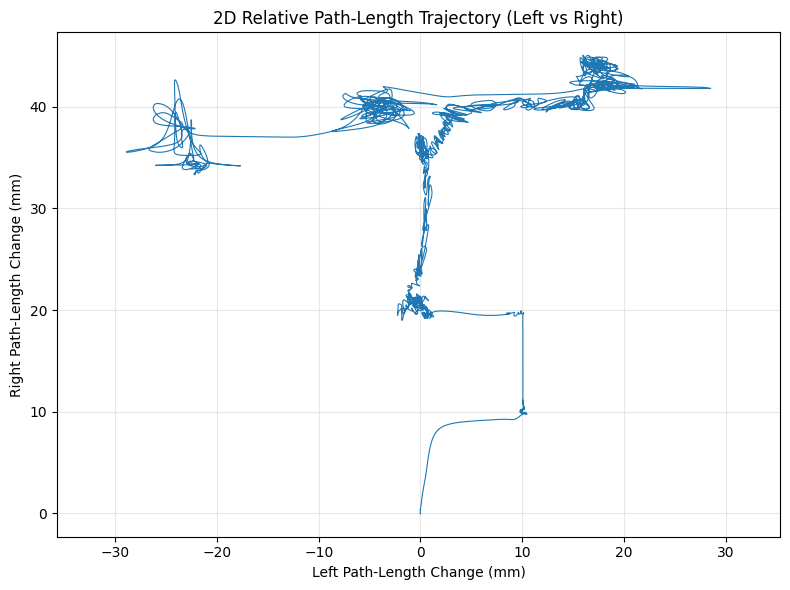

In [25]:
# Plot the normalized I/Q trace for each channel
plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
plt.plot(t_filtered, np.real(filtered_left), linewidth=0.8, label='Left I (In-phase)')
plt.title("Left Channel I/Q Signal - In-phase Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t_filtered, np.imag(filtered_left), linewidth=0.8, label='Left Q (Quadrature)', color='orange')
plt.title("Left Channel I/Q Signal - Quadrature Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t_filtered, np.real(filtered_right), linewidth=0.8, label='Right I (In-phase)')
plt.title("Right Channel I/Q Signal - In-phase Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(t_filtered, np.imag(filtered_right), linewidth=0.8, label='Right Q (Quadrature)', color='orange')
plt.title("Right Channel I/Q Signal - Quadrature Component")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Also plot I/Q constellation for each channel
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(np.real(filtered_left), np.imag(filtered_left), s=1, alpha=0.5)
plt.title("Left Channel I/Q Constellation")
plt.xlabel("I (In-phase)")
plt.ylabel("Q (Quadrature)")
plt.grid(alpha=0.3)
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.scatter(np.real(filtered_right), np.imag(filtered_right), s=1, alpha=0.5)
plt.title("Right Channel I/Q Constellation")
plt.xlabel("I (In-phase)")
plt.ylabel("Q (Quadrature)")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

phase_left = np.unwrap(np.angle(filtered_left))
phase_right = np.unwrap(np.angle(filtered_right))
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_filtered, phase_left, linewidth=0.8)
plt.title("Phase of Downsampled Left-Channel Signal")
plt.xlabel("Time (s)")
plt.ylabel("Phase (radians)")
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(t_filtered, phase_right, linewidth=0.8)
plt.title("Phase of Downsampled Right-Channel Signal")
plt.xlabel("Time (s)")
plt.ylabel("Phase (radians)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Convert unwrapped phase to relative path-length change.
# For the speaker-hand-microphone geometry, phase tracks excess path length relative to the direct path:
# delta_L = lambda * delta_phase / (2 * pi).
speed_of_sound = 343.0  # m/s at room temperature
wavelength = speed_of_sound / carrier_freq
path_change_left = (phase_left - phase_left[0]) * wavelength / (2 * np.pi)
path_change_right = (phase_right - phase_right[0]) * wavelength / (2 * np.pi)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(t_filtered, path_change_left * 1000, linewidth=0.8, label='Left')
plt.title("Relative Path-Length Change from Phase (Left Channel)")
plt.xlabel("Time (s)")
plt.ylabel("Path-Length Change (mm)")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t_filtered, path_change_right * 1000, linewidth=0.8, label='Right', color='orange')
plt.title("Relative Path-Length Change from Phase (Right Channel)")
plt.xlabel("Time (s)")
plt.ylabel("Path-Length Change (mm)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(path_change_left * 1000, path_change_right * 1000, linewidth=0.8)
plt.title("2D Relative Path-Length Trajectory (Left vs Right)")
plt.xlabel("Left Path-Length Change (mm)")
plt.ylabel("Right Path-Length Change (mm)")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()

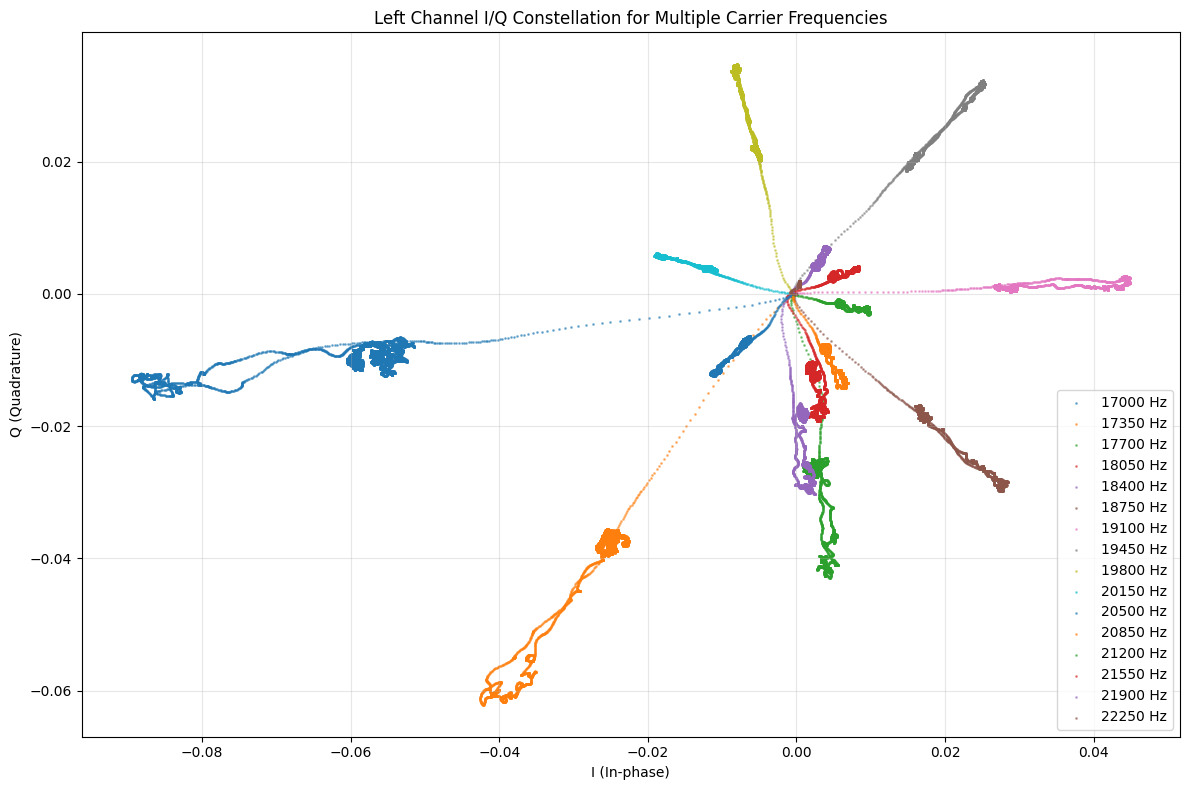

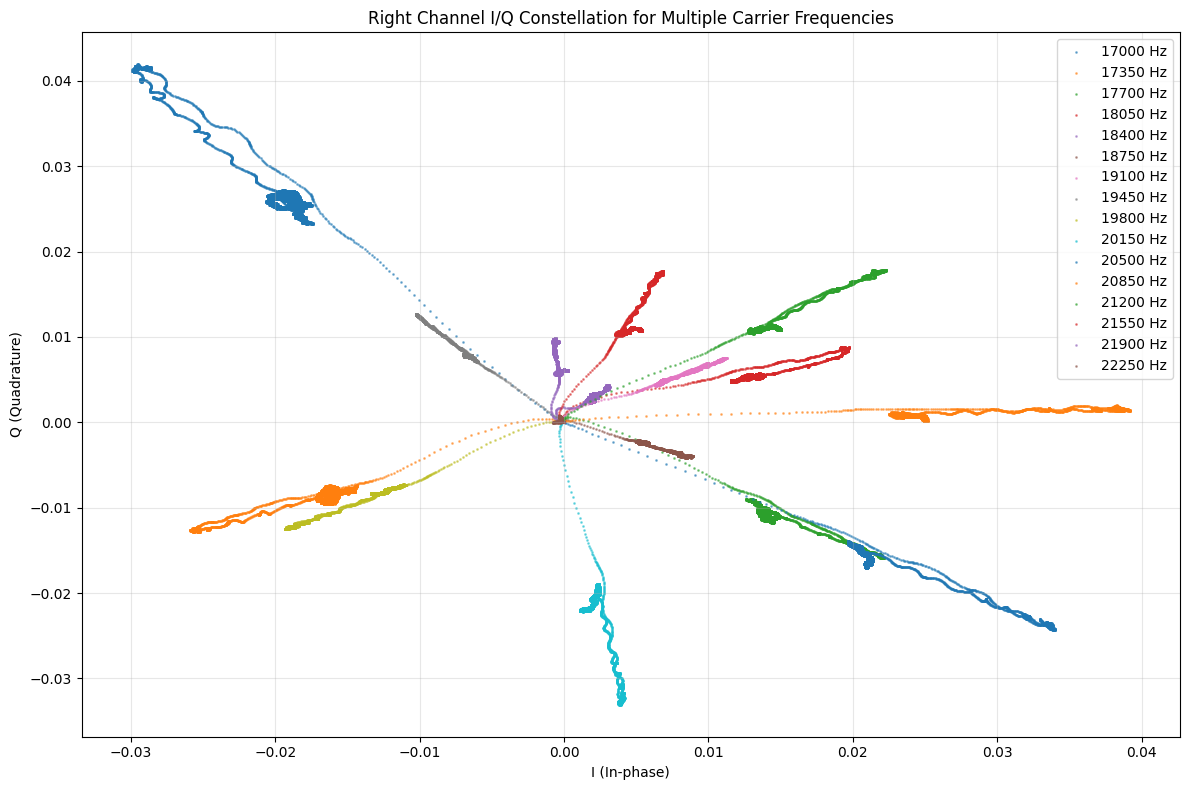

In [26]:
# Graph I/Q constellations for each carrier frequency and each channel separately
for channel_name, channel_audio in [("Left", audio_left), ("Right", audio_right)]:
    plt.figure(figsize=(12, 8))
    for carrier_freq in carrier_freqs:
        downconverted = down_convert(channel_audio, sample_rate, carrier_freq)
        filtered = lowpass_cic_filter(downconverted, decimation_factor, difference_delay, stages)
        plt.scatter(np.real(filtered), np.imag(filtered), s=1, alpha=0.5, label=f'{carrier_freq} Hz')
    plt.title(f"{channel_name} Channel I/Q Constellation for Multiple Carrier Frequencies")
    plt.xlabel("I (In-phase)")
    plt.ylabel("Q (Quadrature)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def extract_path_change_curve(channel_audio, carrier_freq, sample_rate_hz, decimation_factor, difference_delay, stages):
    baseband = down_convert(channel_audio, sample_rate_hz, carrier_freq)
    filtered = lowpass_cic_filter(baseband, decimation_factor, difference_delay, stages)
    # Use 2–3 s window as the static direct-path reference
    dec_rate = int(sample_rate_hz / decimation_factor)
    filtered = filtered - np.mean(filtered[2 * dec_rate : 3 * dec_rate])
    phase = np.unwrap(np.angle(filtered))
    wavelength = 343.0 / carrier_freq
    path_change = (phase - phase[0]) * wavelength / (2 * np.pi)
    return filtered, path_change

def robust_multifreq_combine(path_change_curves, time_axis, sample_rate_hz, window_ms=10.0, min_keep=4, sigma=3.0):
    window_len = max(4, int(round(window_ms * 1e-3 * sample_rate_hz)))
    freq_count, sample_count = path_change_curves.shape
    fused = np.zeros(sample_count, dtype=np.float64)
    kept_counts = np.zeros(sample_count, dtype=np.int32)
    rmse_before = np.zeros(sample_count, dtype=np.float64)
    rmse_after = np.zeros(sample_count, dtype=np.float64)

    for start in range(0, sample_count, window_len):
        end = min(sample_count, start + window_len)
        t_win = time_axis[start:end]
        y_win = path_change_curves[:, start:end]

        coeff_all = np.polyfit(np.tile(t_win, freq_count), y_win.reshape(-1), 1)
        pred_all = np.polyval(coeff_all, t_win)
        residuals = np.sqrt(np.mean((y_win - pred_all[None, :]) ** 2, axis=1))

        median_residual = np.median(residuals)
        mad = np.median(np.abs(residuals - median_residual)) + 1e-12
        threshold = median_residual + sigma * 1.4826 * mad
        keep = residuals <= threshold

        if keep.sum() < min_keep:
            keep = np.zeros(freq_count, dtype=bool)
            keep[np.argsort(residuals)[:min_keep]] = True

        coeff_keep = np.polyfit(np.tile(t_win, int(keep.sum())), y_win[keep].reshape(-1), 1)
        pred_keep = np.polyval(coeff_keep, t_win)

        fused[start:end] = pred_keep
        kept_counts[start:end] = keep.sum()
        rmse_before[start:end] = np.sqrt(np.mean((y_win - pred_all[None, :]) ** 2))
        rmse_after[start:end] = np.sqrt(np.mean((y_win[keep] - pred_keep[None, :]) ** 2))

    return fused, kept_counts, rmse_before, rmse_after

multi_freq_results = {}

for channel_name, channel_audio in [("Left", audio_left), ("Right", audio_right)]:
    path_change_curves = []
    for carrier_freq in carrier_freqs:
        _, path_change_curve = extract_path_change_curve(
            channel_audio,
            carrier_freq,
            sample_rate,
            decimation_factor,
            difference_delay,
            stages,
        )
        path_change_curves.append(path_change_curve)

    path_change_curves = np.stack(path_change_curves, axis=0)
    fused_path_change, kept_counts, rmse_before, rmse_after = robust_multifreq_combine(
        path_change_curves,
        t_filtered,
        new_sample_rate,
        window_ms=10.0,
        min_keep=4,
        sigma=3.0,
    )
    naive_mean = np.mean(path_change_curves, axis=0)

    multi_freq_results[channel_name] = {
        "path_change_curves": path_change_curves,
        "naive_mean": naive_mean,
        "fused_path_change": fused_path_change,
        "kept_counts": kept_counts,
        "rmse_before": rmse_before,
        "rmse_after": rmse_after,
    }

    plt.figure(figsize=(12, 10))
    plt.subplot(3, 1, 1)
    for idx, carrier_freq in enumerate(carrier_freqs):
        plt.plot(t_filtered, path_change_curves[idx] * 1000, linewidth=0.8, alpha=0.35, label=f"{carrier_freq} Hz")
    plt.plot(t_filtered, naive_mean * 1000, linewidth=2.0, linestyle='--', color='tab:blue', label='Before fusion: mean')
    plt.plot(t_filtered, fused_path_change * 1000, linewidth=2.0, color='black', label='After fusion: robust linear regression')
    plt.title(f"{channel_name} Channel Path-Length Change Curves Across 16 Frequencies")
    plt.xlabel("Time (s)")
    plt.ylabel("Path-Length Change (mm)")
    plt.grid(alpha=0.3)
    plt.legend(ncol=3, fontsize=8)

    plt.subplot(3, 1, 2)
    plt.plot(t_filtered, naive_mean * 1000, linewidth=1.8, linestyle='--', color='tab:blue', label='Before fusion: mean')
    plt.plot(t_filtered, fused_path_change * 1000, linewidth=1.8, color='black', label='After fusion: robust fit')
    plt.title(f"{channel_name} Channel Before vs After Multi-Frequency Fusion")
    plt.xlabel("Time (s)")
    plt.ylabel("Path-Length Change (mm)")
    plt.grid(alpha=0.3)
    plt.legend()

    plt.subplot(3, 1, 3)
    plt.plot(t_filtered, kept_counts, linewidth=1.5, color='tab:green', label='Frequencies kept')
    plt.plot(t_filtered, rmse_before * 1000, linewidth=1.2, color='tab:red', alpha=0.8, label='RMSE before (mm)')
    plt.plot(t_filtered, rmse_after * 1000, linewidth=1.2, color='tab:orange', alpha=0.8, label='RMSE after (mm)')
    plt.title(f"{channel_name} Channel Regression Diagnostics")
    plt.xlabel("Time (s)")
    plt.ylabel("Count / Error")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

left_before = multi_freq_results["Left"]["naive_mean"] * 1000
right_before = multi_freq_results["Right"]["naive_mean"] * 1000
left_after = multi_freq_results["Left"]["fused_path_change"] * 1000
right_after = multi_freq_results["Right"]["fused_path_change"] * 1000

plt.figure(figsize=(10, 8))
plt.plot(left_before, right_before, linewidth=1.2, linestyle='--', color='tab:blue', label='Before fusion: mean across frequencies')
plt.plot(left_after, right_after, linewidth=1.6, color='black', label='After fusion: robust multifrequency regression')
plt.title("2D Path-Length Trajectory Before vs After Multi-Frequency Fusion")
plt.xlabel("Left Path-Length Change (mm)")
plt.ylabel("Right Path-Length Change (mm)")
plt.grid(alpha=0.3)
plt.axis('equal')
plt.legend()
plt.tight_layout()
plt.show()